Here we want to compare the differences between stacks from various groups.

In [1]:
import numpy as np
import obspy
import lfeanalysis
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from '/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py'>

### 1. Load and prepare the data

This reads in the data and does some grouping by time.

In [2]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfanalyse(fnum=156)

# and load in the detections and waveforms
lf.load_prep_data(flm=[1,8],single_norm=False)

Reading data
Normalizing data
Filtering data


### 2. Stack

In [3]:
# stack for each group
lf.stack_by_group()

# and pick arrival times
lf.pick_stacks(minsnr=10)

### 3. Read in information about the station locations

We need this because we'll want to project the ground velocities along and perpendicular to the ray paths.

In [4]:
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(fnum=156,lfi=lf)

# read the station locations
lf.read_station_locations()

# this provides a dictionary of the station locations
print('Station locations:\n',lf.statloc)
ky=list(lf.statloc.keys())[0]

fmt='\nStation {:s} is a longitude {:0.2f}, latitude {:0.2f}'
print(fmt.format(ky,lf.statloc[ky][0],lf.statloc[ky][1]))



Station locations:
 {'BPCB': array([-123.7045,   48.9236,   31.    ]), 'KHVB': array([-123.4663,   48.5688,   39.    ]), 'MGCB': array([-123.6808,   48.6317,  236.    ]), 'SHDB': array([-123.636,   48.797,   55.   ]), 'SHVB': array([-123.636 ,   48.4723,   69.    ]), 'LZB': array([-123.824 ,   48.6122,  794.    ]), 'NLLB': array([-123.9882,   49.2271,  199.    ]), 'PGC': array([-123.4521,   48.6498,   12.    ]), 'YOUB': array([-124.2618,   48.901 ,  771.    ]), 'B926': array([-124.131203,   48.820202,  191.6     ]), 'KLNB': array([-123.5706,   48.6611,    0.    ]), 'SILB': array([-123.2815,   48.602 ,   76.    ]), 'SSIB': array([-123.3875,   48.7558,   12.    ]), 'TWKB': array([-123.7332,   48.6448,  128.    ])}

Station BPCB is a longitude -123.70, latitude 48.92


/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/obspy/core/inventory/network.py:321: UserWarning: Found more than one matching channel metadata. Returning first.
  warnings.warn(msg)


In [5]:
# and compute the station location relative to the LFE family we're working with
print('LFE longitude, latitude, depth (in km)',lf.floc)

lf.relative_station_locations()

print('Station {:s} is located {:0.0f} km from the LFE, horizontally'.format(ky,lf.statdst[ky]))
print('It is at azimuth {:0.0f} from the LFE'.format(lf.stataz[ky]))

# alternatively the relative station locations in [E,N] components (km) are in lf.statxy
print('\nE-N station locations (km): \n',lf.statxy)

LFE longitude, latitude, depth (in km) [-123.6187   48.5193   36.96  ]
Station BPCB is located 45 km from the LFE, horizontally
It is at azimuth 352 from the LFE

E-N station locations (km): 
 {'BPCB': array([-6.28778736, 44.96344799]), 'KHVB': array([11.24731983,  5.51565359]), 'MGCB': array([-4.57737963, 12.50090872]), 'SHDB': array([-1.27101344, 30.88124746]), 'SHVB': array([-1.27919096, -5.2262534 ]), 'LZB': array([-15.13843605,  10.35093105]), 'NLLB': array([-26.9144179 ,  78.77776667]), 'PGC': array([12.27565702, 14.52519905]), 'YOUB': array([-47.14976214,  42.64524301]), 'B926': array([-37.63545036,  33.58760507]), 'KLNB': array([ 3.54338343, 15.76952906]), 'SILB': array([24.86944891,  9.25119017]), 'SSIB': array([16.99989089, 26.32516824]), 'TWKB': array([-8.43758814, 13.96212521])}


### 3. Compute scalings between the stacks

The next line grabs out a four-second interval of each stack, starting at time marker t0.

Then it computes how much you would have to multiply the average stack (lf.totstk) by to recover the grouped stack (lf.grpstk).  We compute one scaling factor per station (lf.scalings) or one scaling factor per component (lf.scalingsc).

Note, however, that the scaling factors per component have been divided by the scaling computed per station.

In [6]:
# now we can compute scalings between the stacks
lf.compute_scalings(wlen=[0,4])

# the scalings between the average and the groups, as averaged over components are here
print('Scalings per station:\n',lf.scalings)

# and the scalings computed per component are here
# R indicates the radial component
# T indicates the transverse component
print('\nScalings per component, divided by station average:\n',lf.scalingsc)

Scalings per station:
 {'early': {'B926': 0.8721150887842329, 'KHVB': 0.6666216707364694, 'LZB': 0.9131818778286377, 'MGCB': 0.8066787023333352, 'NLLB': 1.0092125745466212, 'PGC': 0.9303865758125268, 'SHDB': 0.9489847260121965, 'SHVB': 0.9230204686611475, 'YOUB': 0.818821681302376}, 'late': {'B926': 1.3000398278209468, 'KHVB': 1.2382222175283564, 'LZB': 1.255467676022041, 'MGCB': 1.1787927387454173, 'NLLB': 1.2192125302058696, 'PGC': 1.1780741709056657, 'SHDB': 1.0747104282608617, 'SHVB': 1.1069371016713214, 'YOUB': 1.3478993772082428}}

Scalings per component, divided by station average:
 {'early': {'B926': {'E': 1.0275794422214561, 'N': 1.001683367752416, 'Z': 0.9317807471307941, 'R': 0.9675760339495391, 'T': 1.142503997690802}, 'KHVB': {'E': 1.0083859844130747, 'N': 0.9938038178780483, 'Z': 1.0315137898149611, 'R': 1.023542978058415, 'T': 0.9627288908894385}, 'LZB': {'E': 1.0214012119827187, 'N': 0.9929731517045578, 'Z': 0.9974873698102104, 'R': 1.0034594989803596, 'T': 0.9979823529

Scaling factor for station MGCB: 0.807


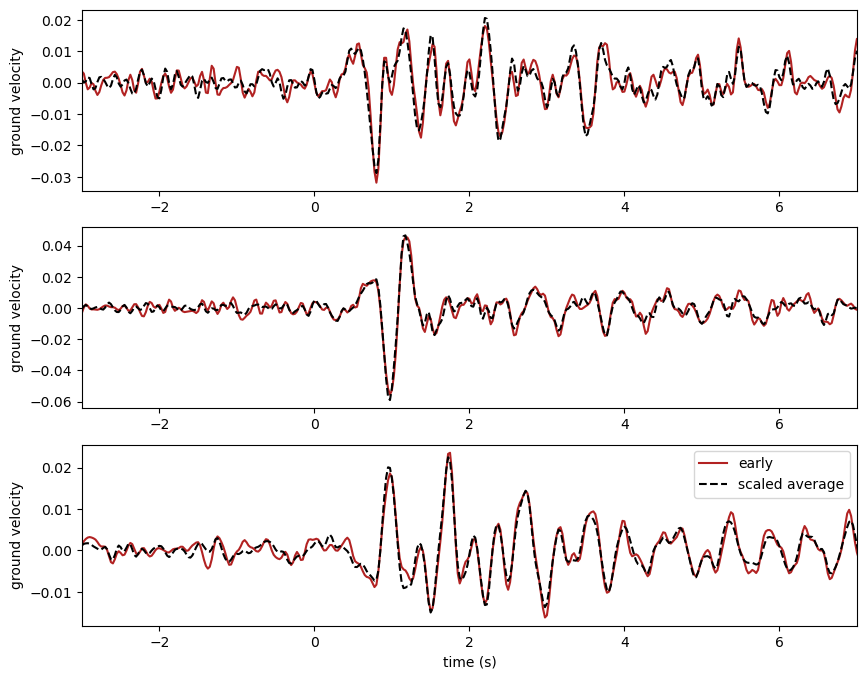

In [7]:
# let's check that the scaling seems sensible
stn='MGCB'
chns=['E','N','Z']
Nc=len(chns)

f=plt.figure(figsize=(10,8))
for kc in range(0,Nc):
    chn=chns[kc]
    ph=plt.subplot(Nc,1,kc+1)
    # the early stack
    tre=lf.grpstk['early'].select(station=stn,channel=chn)[0]    
    trt=lf.totstk.select(station=stn,channel=chn)[0]

    # plot
    ph.plot(trt.times()-trt.stats.t0,tre.data,
             color='firebrick',linestyle='-',label='early')
    ph.plot(trt.times()-trt.stats.t0,trt.data*lf.scalings['early'][stn],
             color='k',linestyle='--',label='scaled average')
    ph.set_xlim([-3,7])
    ph.set_ylabel('ground velocity');
    
ph.set_xlabel('time (s)');
ph.legend();

print('Scaling factor for station {:s}: {:0.3f}'.format(stn,lf.scalings['early'][stn]))

Scaling factor adjustment for MGCB.E: 0.967
Scaling factor adjustment for MGCB.N: 1.014
Scaling factor adjustment for MGCB.Z: 0.997
Scaling factor for station MGCB: 0.807


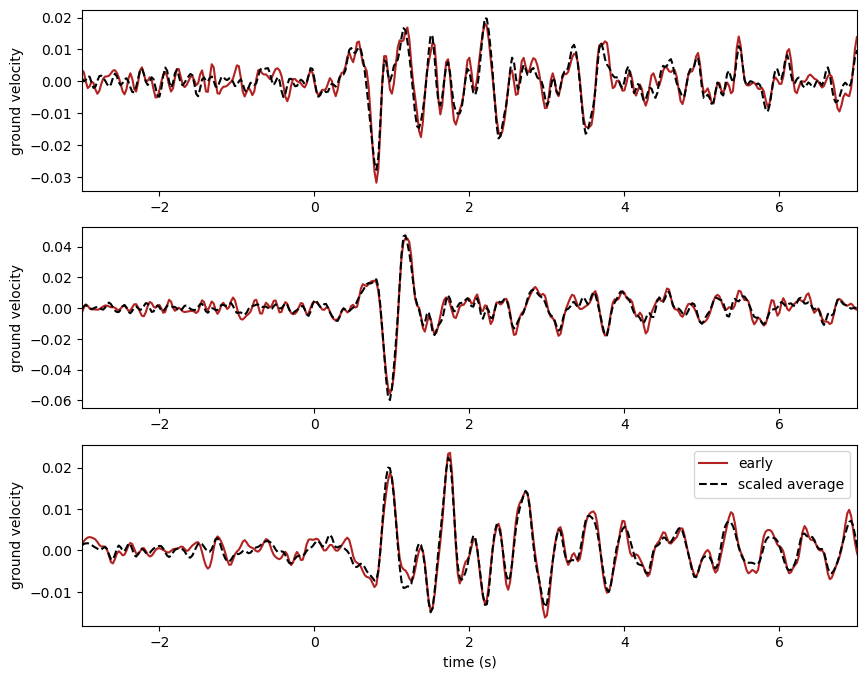

In [8]:
# let's check that the scaling seems sensible
stn='MGCB'
chns=['E','N','Z']
Nc=len(chns)

f=plt.figure(figsize=(10,8))
for kc in range(0,Nc):
    chn=chns[kc]
    ph=plt.subplot(Nc,1,kc+1)
    # the early stack
    tre=lf.grpstk['early'].select(station=stn,channel=chn)[0]    
    trt=lf.totstk.select(station=stn,channel=chn)[0]

    # plot
    scl=lf.scalingsc['early'][stn][chn]*lf.scalings['early'][stn]
    ph.plot(trt.times()-trt.stats.t0,tre.data,
             color='firebrick',linestyle='-',label='early')
    ph.plot(trt.times()-trt.stats.t0,trt.data*scl,
             color='k',linestyle='--',label='scaled average')
    ph.set_xlim([-3,7])
    ph.set_ylabel('ground velocity');
    
    print('Scaling factor adjustment for {:s}.{:s}: {:0.3f}'.format(stn,chn,lf.scalingsc['early'][stn][chn]))
    
ph.set_xlabel('time (s)');
ph.legend();

print('Scaling factor for station {:s}: {:0.3f}'.format(stn,lf.scalings['early'][stn]))

### 4. Note bootstrapped scalings

We redo this scaling analysis with the bootstrapped stacks.

In [9]:
# the bootstrapped per-station scalings are here
# there is now a list of scalings per station
print('Per-station bootstrapped scalings:\n',lf.scalingsb)

# and likewise the per-component scalings are here
# again with a list of scalings per component
print('\nPer-component bootstrapped scalings:\n',lf.scalingscb)

Per-station bootstrapped scalings:
 {'early': {'B926': array([0.87049686, 0.85241306, 0.87068047, 0.83998777, 0.86172498,
       0.80407771, 0.93304662, 0.864152  , 0.91015664, 0.86053213]), 'KHVB': array([0.71716599, 0.62065781, 0.67316649, 0.77031461, 0.67887499,
       0.73673405, 0.58248369, 0.70788784, 0.73624249, 0.58385308]), 'LZB': array([0.9412931 , 0.86272233, 0.91463308, 0.99353766, 0.98923225,
       0.92646141, 0.87240227, 0.904884  , 0.94484306, 0.98614532]), 'MGCB': array([0.78338942, 0.74340337, 0.87878545, 0.82109616, 0.87099026,
       0.83265227, 0.76496708, 0.8629824 , 0.77739772, 0.80107136]), 'NLLB': array([1.00685374, 1.01957388, 1.10518807, 0.96840138, 0.98051716,
       0.96185271, 1.01537603, 1.01727121, 0.99445407, 0.9891684 ]), 'PGC': array([0.86692283, 0.94103211, 0.89576685, 0.92719473, 0.9392003 ,
       0.91415091, 0.96035269, 0.95187439, 0.97135442, 0.91633335]), 'SHDB': array([0.97642878, 0.86764192, 0.98818043, 1.08092074, 0.91747958,
       1.0100407

### 5. Normalize the energy between the transverse and radial components

We are mostly interested in whether the early and late stacks are scaled-up more on the radial or  transverse components.

In [10]:
# let's have a look at the radial and transverse scalings for the late stack on one station
stn=list(lf.scalingsc['late'].keys())[1]
scls=lf.scalingsc['late'][stn]

print('Radial scaling at station {:s}: {:0.03}'.format(ky,scls['R']))
print('Transverse scaling at station {:s}: {:0.03}'.format(ky,scls['T']))

Radial scaling at station BPCB: 0.985
Transverse scaling at station BPCB: 1.02


We can just compare these numbers and ask which is bigger: the radial scaling $A_r$ or the transverse scaling $A_t$.  But since we'll want to compare between the early and late stacks, it makes sense to normalize somehow to decide how much bigger.  So we'll compute the normalized scalings

$$A_r' = \frac{A_r}{\sqrt{2(A_r^2+A_t^2)}}$$

$$A_t' = \frac{A_t}{\sqrt{2(A_r^2+A_t^2)}}$$

where the factor of 2 is just so that the scalings always stay close to 1.

In [11]:
# the total scaling energy
totscl=np.sqrt((scls['R']**2+scls['T']**2)/2)
print(totscl)

print('Normalized radial scaling at station {:s}: {:0.03}'.format(ky,scls['R']/totscl))
print('Normalized transverse scaling at station {:s}: {:0.03}'.format(ky,scls['T']/totscl))

1.0024648141971944
Normalized radial scaling at station BPCB: 0.982
Normalized transverse scaling at station BPCB: 1.02


In [12]:
# let's go ahead and normalize the radial and transverse scalings for all stations
lf.normalize_radtrans_scaling()

scls=lf.scalingsc['early'][stn]
print('Normalized early radial scaling at station {:s}: {:0.03}'.format(ky,scls['R']))
print('Normalized early transverse scaling at station {:s}: {:0.03}'.format(ky,scls['T']))

scls=lf.scalingsc['late'][stn]
print('\nNormalized late radial scaling at station {:s}: {:0.03}'.format(ky,scls['R']))
print('Normalized late transverse scaling at station {:s}: {:0.03}'.format(ky,scls['T']))

Normalized early radial scaling at station BPCB: 1.03
Normalized early transverse scaling at station BPCB: 0.969

Normalized late radial scaling at station BPCB: 0.982
Normalized late transverse scaling at station BPCB: 1.02


### 6. Note the takeoff angles from the LFE family to the stations

{'BPCB': array([108.89615551]), 'KHVB': array([156.37597562]), 'MGCB': array([154.97581136]), 'SHDB': array([127.27220845]), 'SHVB': array([169.63165049]), 'LZB': array([146.34133042]), 'NLLB': array([92.73627811]), 'PGC': array([145.22009458]), 'YOUB': array([95.94633628]), 'B926': array([103.61462531]), 'KLNB': array([150.00866931]), 'SILB': array([133.51935859]), 'SSIB': array([126.67753604]), 'TWKB': array([149.75083104])}


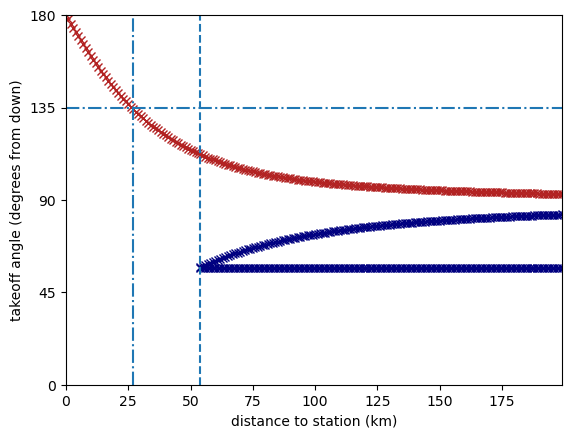

In [13]:
# first make a grid of a range of distances
lf.grid_takeoff_angles(plot=True)

# each curve gives the angle from the downgoing vertical to the wave takeoff direction
# there are multiply curves because there are multiple waves leaving the LFE

# and then compute the takeoff angle per station
lf.find_takeoff_angles()

# the resulting takeoff values are here
print(lf.takeoff_angles)

### 7. Plot the scalings by location

Here we'll plot the change in the radial or transverse component between the early and late stacks.

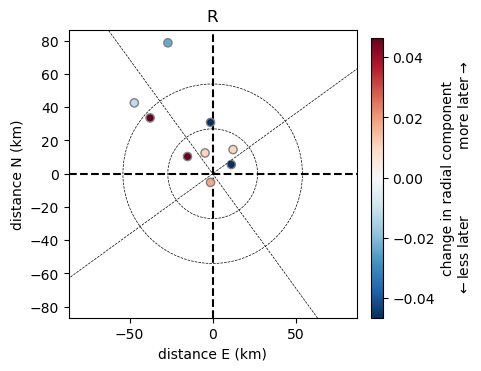

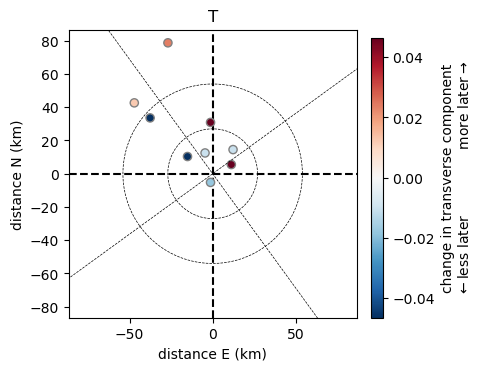

In [14]:
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(fnum=156,lfi=lf)

# the radial scaling change as a function of station location relative to the LFE
# lines are plotted in the plate convergence direction and perpendicular to convergence
lf.plot_scaling_by_location(cplot=['R'])

# alternatively, the transvers scaling change as a function of station location
lf.plot_scaling_by_location(cplot=['T'])

### 7. Plot a histogram of the scaling differences

/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:2189: RuntimeWarning: invalid value encountered in scalar divide
  frcneg=np.sum(bmdn<0)/np.sum(bmdn<float('inf'))
/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6762: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/home/users/eart0448/SPROGRAMS/miniconda3/envs/strain/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6763: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


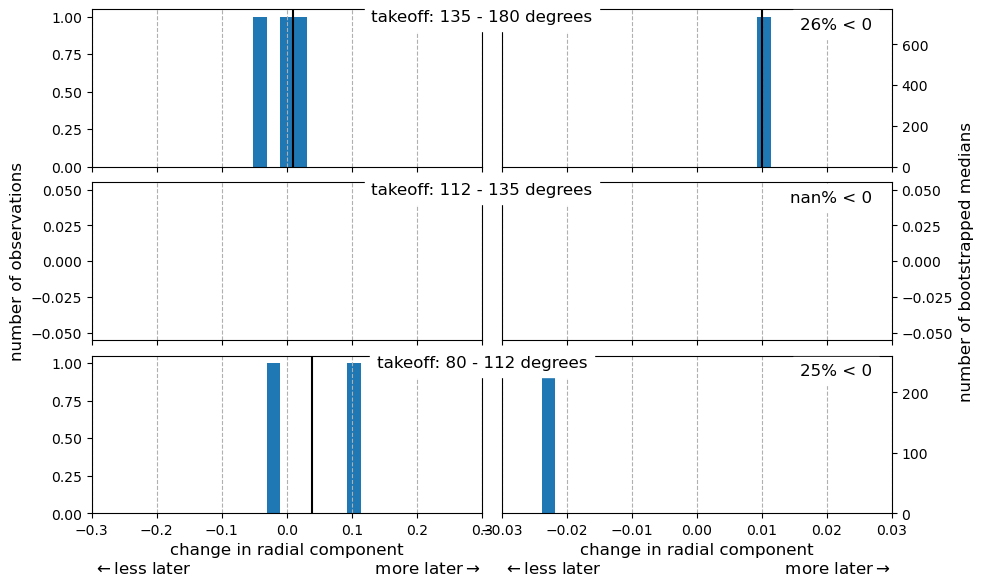

In [15]:
# there aren't many values here, but we can still have a start looking at the distributions
# the left column bins all the values, and the vertical line is the mean or median
# the right column recomputes the average multiple times, 
# bootstrapping by station or stack distribution, and plots the distribution of those values
lf.plot_binned_coefficients(chn='R',avetype='median')